# 1. Data Ingestion

In this section I will create the setup for the project, alongside creating the process of ingestion of relevant financial data.
We will also create a simple light-weight data pipeline to clean this data and represent it.

## 1.1 Set file path

Here I set the file path to ensure the Jupyter notebook can be run on any system, no hardset file paths.

In [1]:
import sys
from pathlib import Path

# Try to locate the project root by looking for a directory that contains 'src'
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]

PROJECT_ROOT = None
for path in candidate_roots:
    if (path / "src").exists():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find project root containing 'src'.")

# Add project root to Python path so 'from src...' imports work
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root set to: {PROJECT_ROOT}")


Project root set to: C:\Users\User\git\personal_projects\market-regimes-trading-signals\market-regimes-trading-signals


## 1.2 Data Configuration

Here I imported our config file and set these to our local DataConfig to be used within the notebook.
I then verify the data is loaded and of the correct form by revealing the head and tail.

In [2]:
from src.config import (
    PROJECT_ROOT,
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    TICKERS,
    START_DATE,
    END_DATE,
)
from src.data import DataConfig, build_and_save_market_dataset

In [ ]:
config = DataConfig(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
    raw_dir=DATA_RAW_DIR,
    processed_dir=DATA_PROCESSED_DIR,
)

df = build_and_save_market_dataset(config)
df.head()

Here I print the latest 5 rows, showing our most recent date of information.

In [ ]:
df.tail()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close
date,,,,,,,
2026-03-24,653.179993,653.179993,96457500,26.950001,26.950001,4.392,4.392
2026-03-25,656.820007,656.820007,90653800,25.330000,25.330000,4.328,4.328
2026-03-26,645.090027,645.090027,96494400,27.440001,27.440001,4.416,4.416
2026-03-27,634.090027,634.090027,102725900,31.049999,31.049999,4.440,4.440
2026-03-30,638.304993,638.304993,5576464,29.750000,29.750000,4.354,4.354


## 1.3 Data Representation

Here I plot the SPY Adjusted Close, the VIX Close and the 10Y Treasury Yield proxy together to initially model their relationship together.

From below we can see a strong upwards trend for the SPY adjusted close, alongside a strong dip coinciding with the peak of the VIX Close at around 2020. It is worth noting here that this also aligns with a low point in the 10Y Treasury Yield Proxy.

array([<Axes: title={'center': 'SPY Adjusted Close'}, xlabel='date'>,
       <Axes: title={'center': 'VIX Close'}, xlabel='date'>,
       <Axes: title={'center': '10Y Treasury Yield Proxy'}, xlabel='date'>],
      dtype=object)

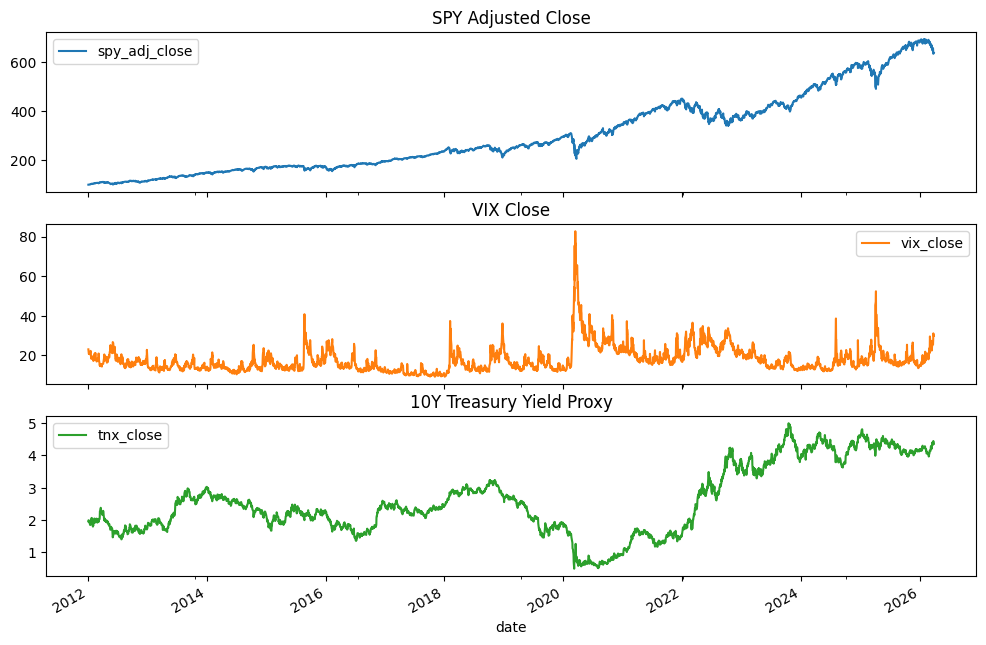

In [ ]:
df[["spy_adj_close", "vix_close", "tnx_close"]].plot(
    subplots=True,
    figsize=(12, 8),
    title=["SPY Adjusted Close", "VIX Close", "10Y Treasury Yield Proxy"],
)

# 2. Feature Engineering

In this section, I construct a set of interpretable features designed to capture
the key dimensions of market behaviour relevant for regime classification.

Rather than using complex models or large feature sets, I focus on a small number
of variables that reflect:

- **direction (trend)** of the market  
- **instability (volatility)**  
- **market stress (drawdown)**  
- **broader risk context (VIX and interest rates)**  

The goal is not to predict short-term price movements, but to build a structured
representation of market conditions that can later be used to define regimes.

In [ ]:
from src.features import (
    add_all_features,
    get_available_feature_columns,
    summarize_feature_coverage,
    drop_feature_warmup_rows,
)

features_df = add_all_features(df).copy()

print(f"Feature dataframe shape: {features_df.shape}")
features_df.head()

Feature dataframe shape: (3580, 17)


,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close,spy_ret_1d,spy_ma_50,spy_ma_200,spy_trend_signal,spy_rv_20,spy_rv_60,spy_drawdown_252,vix_level,vix_change_20,tnx_change_20
date,,,,,,,,,,,,,,,,,
2012-01-03,127.500000,99.312195,193697900,22.969999,22.969999,1.960,1.960,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,22.969999,NaN,NaN
2012-01-04,127.699997,99.467964,127186500,22.219999,22.219999,1.995,1.995,0.001568,NaN,NaN,NaN,NaN,NaN,0.000000,22.219999,NaN,NaN
2012-01-05,128.039993,99.732796,173895000,21.480000,21.480000,1.993,1.993,0.002662,NaN,NaN,NaN,NaN,NaN,0.000000,21.480000,NaN,NaN
2012-01-06,127.709999,99.475769,148050000,20.629999,20.629999,1.961,1.961,-0.002577,NaN,NaN,NaN,NaN,NaN,-0.002577,20.629999,NaN,NaN
2012-01-09,128.020004,99.717232,99530200,21.070000,21.070000,1.960,1.960,0.002427,NaN,NaN,NaN,NaN,NaN,-0.000156,21.070000,NaN,NaN


## 2.1 Feature Overview

The first version of the feature set includes:

- **Returns**
  - `spy_ret_1d`: daily percentage return

- **Trend**
  - `spy_ma_50`: 50-day moving average
  - `spy_ma_200`: 200-day moving average
  - `spy_trend_signal`: indicator for whether the short-term trend is above the long-term trend

- **Volatility**
  - `spy_rv_20`: short-term realized volatility (20 days)
  - `spy_rv_60`: medium-term realized volatility (60 days)

- **Drawdown**
  - `spy_drawdown_252`: distance from the rolling one-year peak

- **Macro / Risk Proxies**
  - `vix_level`: implied volatility index
  - `vix_change_20`: change in market fear over 20 days
  - `tnx_change_20`: change in interest rates over 20 days

These features are intentionally simple and interpretable, which is important for
understanding and explaining regime behaviour.

In [ ]:
available_feature_cols = get_available_feature_columns(features_df)
features_df[available_feature_cols].tail()

,spy_ret_1d,spy_ma_50,spy_ma_200,spy_trend_signal,spy_rv_20,spy_rv_60,spy_drawdown_252,vix_level,vix_change_20,tnx_change_20
date,,,,,,,,,,
2026-03-24,-0.003357,680.638463,657.186614,1.0,0.132546,0.120975,-0.058270,26.950001,0.378517,0.359
2026-03-25,0.005573,679.909530,657.508966,1.0,0.129806,0.121681,-0.053022,25.330000,0.412716,0.280
2026-03-26,-0.017859,678.973721,657.769999,1.0,0.140526,0.126522,-0.069934,27.440001,0.472893,0.399
2026-03-27,-0.017052,677.885927,657.959224,1.0,0.148929,0.130733,-0.085793,31.049999,0.563444,0.478
2026-03-30,0.006647,676.844934,658.178027,1.0,0.152779,0.131081,-0.079716,29.750000,0.387593,0.306


## 2.2 Data Quality and Missing Values

Rolling features such as moving averages and volatility require a lookback window,
which naturally introduces missing values at the start of the sample.

This is expected and does not indicate an issue with the data.

The main checks here are:
- missing values are concentrated at the beginning of the sample
- core price series are complete after alignment

In [ ]:
summarize_feature_coverage(features_df)

,missing_count,missing_pct
spy_trend_signal,199,0.055587
spy_ma_200,199,0.055587
spy_rv_60,60,0.016760
spy_ma_50,49,0.013687
tnx_change_20,20,0.005587
spy_rv_20,20,0.005587
vix_change_20,20,0.005587
spy_ret_1d,1,0.000279
vix_level,0,0.000000
spy_drawdown_252,0,0.000000


## 2.3 Trend Features

Trend is one of the most fundamental characteristics of financial markets.

I use a simple moving average crossover framework:
- a **50-day moving average** to capture shorter-term dynamics
- a **200-day moving average** to capture longer-term structure

The derived signal (`spy_trend_signal`) indicates whether the short-term trend
is stronger than the long-term trend.

This is not intended to be a trading signal in isolation, but rather a high-level
indicator of whether the market is broadly trending upward or downward.

<Axes: title={'center': 'SPY with 50-Day and 200-Day Moving Averages'}, xlabel='date'>

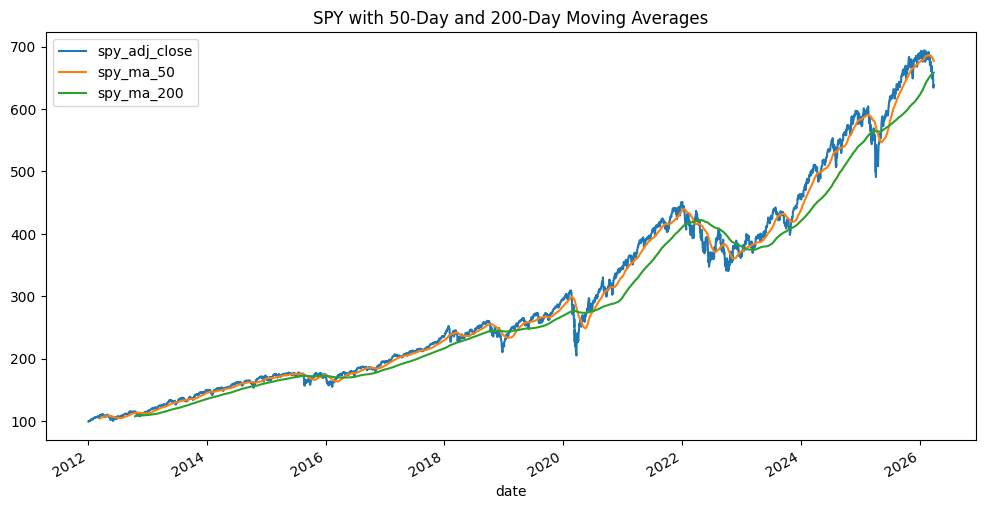

In [ ]:
features_df[["spy_adj_close", "spy_ma_50", "spy_ma_200"]].plot(
    figsize=(12, 6),
    title="SPY with 50-Day and 200-Day Moving Averages",
)

In [ ]:
features_df["spy_trend_signal"].value_counts(dropna=False)

spy_trend_signal
1.0    2847
0.0     534
NaN     199
Name: count, dtype: int64

The moving average crossover provides a simple and interpretable way to distinguish
between bullish and bearish market environments, without relying on complex modelling.

## 2.4 Realized Volatility

Volatility is a key component of market regimes.

Periods of low volatility are typically associated with stable, risk-on environments,
while spikes in volatility often coincide with stress events or market corrections.

I compute annualized realized volatility over:
- 20 trading days (short-term)
- 60 trading days (medium-term)

This allows comparison between recent and more persistent volatility conditions.

<Axes: title={'center': 'SPY Realized Volatility (20D and 60D)'}, xlabel='date'>

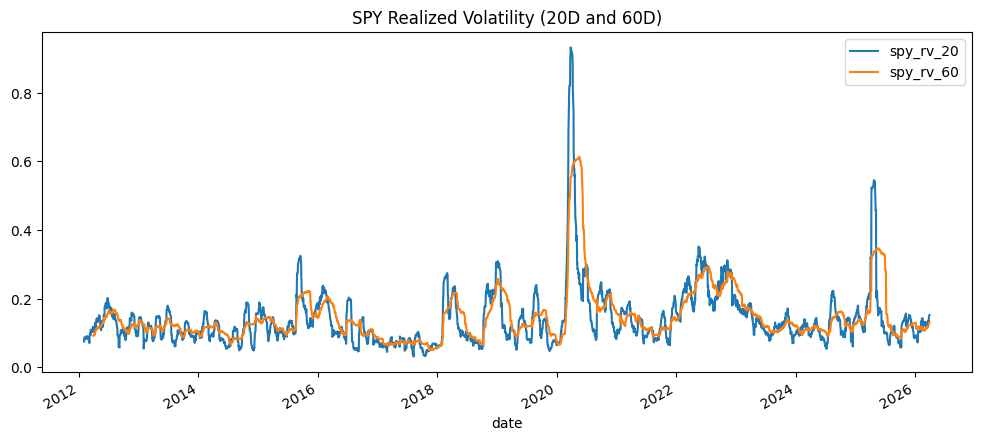

In [ ]:
features_df[["spy_rv_20", "spy_rv_60"]].plot(
    figsize=(12, 5),
    title="SPY Realized Volatility (20D and 60D)",
)

Higher volatility levels will later be used as an indicator of potential stress
or transition regimes.

## 2.5 Drawdown

While volatility captures instability, it does not fully reflect cumulative losses.

Drawdown measures how far the market has fallen from its recent peak and is a useful
indicator of sustained stress.

I compute a trailing 252-day drawdown (approximately one year), which provides a
medium-term measure of market damage.

<Axes: title={'center': 'SPY Trailing Drawdown'}, xlabel='date'>

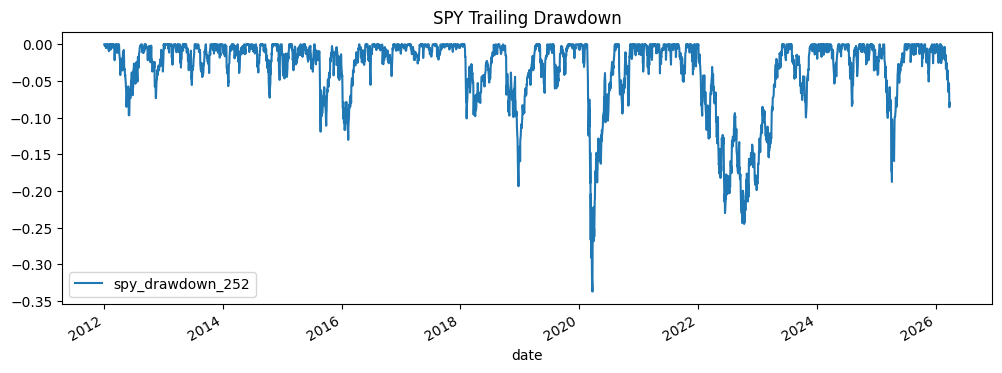

In [ ]:
features_df[["spy_drawdown_252"]].plot(
    figsize=(12, 4),
    title="SPY Trailing Drawdown",
)

Drawdowns help distinguish between normal fluctuations and more severe market declines.

## 2.6 Macro and Risk Context

To complement price-based features, I include two simple macro indicators:

- **VIX (implied volatility)**:
  captures market expectations of future volatility and is often interpreted
  as a measure of fear or uncertainty.

- **Treasury yield changes**:
  reflect shifts in the interest rate environment, which can affect equity
  valuations and broader financial conditions.

These variables provide additional context beyond SPY price movements alone.

In [ ]:
macro_cols = [col for col in ["vix_level", "vix_change_20", "tnx_change_20"] if col in features_df.columns]
features_df[macro_cols].tail()

,vix_level,vix_change_20,tnx_change_20
date,,,
2026-03-24,26.950001,0.378517,0.359
2026-03-25,25.330000,0.412716,0.280
2026-03-26,27.440001,0.472893,0.399
2026-03-27,31.049999,0.563444,0.478
2026-03-30,29.750000,0.387593,0.306


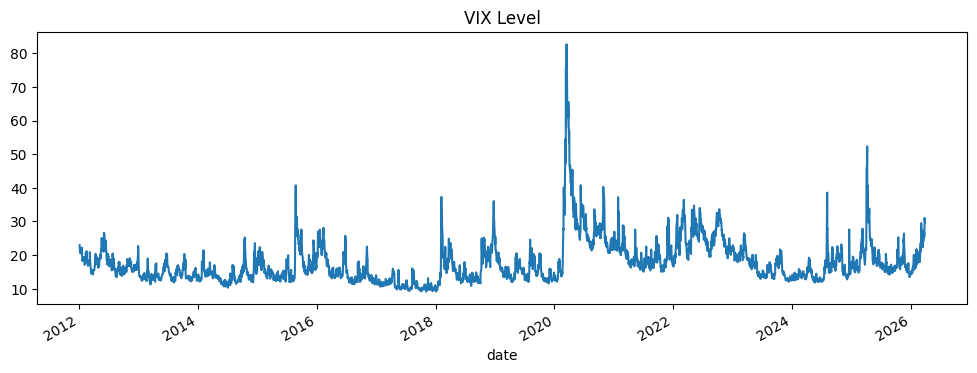

In [ ]:
if "vix_level" in features_df.columns:
    features_df["vix_level"].plot(
        figsize=(12, 4),
        title="VIX Level",
    )

Movements in VIX are particularly useful for identifying transitions between
risk-on and risk-off environments.

## 2.7 Feature Stabilization

Because many features rely on rolling calculations, it is useful to remove
the initial warm-up period before further analysis.

This ensures that all key indicators are fully defined.

In [ ]:
clean_features_df = drop_feature_warmup_rows(features_df)

print(f"Rows after warm-up: {clean_features_df.shape[0]}")
clean_features_df[available_feature_cols].head()

Rows after warm-up: 3381


,spy_ret_1d,spy_ma_50,spy_ma_200,spy_trend_signal,spy_rv_20,spy_rv_60,spy_drawdown_252,vix_level,vix_change_20,tnx_change_20
date,,,,,,,,,,
2012-10-16,0.010133,112.957232,107.607940,1.0,0.094060,0.108537,-0.006269,15.220000,0.073343,-0.092
2012-10-17,0.004535,113.061985,107.689296,1.0,0.095471,0.106720,-0.001763,15.070000,0.085735,0.029
2012-10-18,-0.002599,113.158056,107.768371,1.0,0.095956,0.107029,-0.004358,15.030000,0.068230,0.049
2012-10-19,-0.016664,113.213819,107.836516,1.0,0.112714,0.108779,-0.020949,17.059999,0.220315,0.008
2012-10-22,0.000140,113.266280,107.906026,1.0,0.112734,0.102518,-0.020813,16.620001,0.174558,0.080


## 2.8 Summary

At this stage, the feature set captures four core aspects of market behaviour:

1. **Trend** (moving averages)  
2. **Volatility** (realized volatility)  
3. **Stress** (drawdown)  
4. **Macro context** (VIX and interest rates)  

These features provide a structured and interpretable basis for defining market regimes.

The next step is to translate these indicators into a small number of discrete
regime labels.

# 3. Market Regime Classification

Using the engineered features, I classify each day into a discrete market regime.

The objective is not to predict short-term returns directly, but to organize market conditions into a small number of interpretable states that reflect trend, volatility, and market stress.

## 3.1 Regime Design

The regime classification is rule-based and intentionally designed to remain interpretable.

The four regimes are:

- **Risk-on**: positive trend with calm volatility conditions
- **Recovery**: positive trend, but volatility remains elevated and is improving
- **Stress**: negative trend or unstable market conditions without full capitulation
- **Risk-off**: severe stress, characterized by high implied volatility, deep drawdowns, or both

In addition to fixed thresholds such as VIX levels, the classification also uses rolling realized-volatility context so that current volatility can be judged relative to recent market history.

In [ ]:
from src.regimes import (
    assign_regimes,
    get_known_regime_subset,
    get_regime_counts,
    get_regime_distribution,
    summarize_regime_returns,
)

In [ ]:
regime_df = assign_regimes(clean_features_df)
regime_df.head()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close,spy_ret_1d,spy_ma_50,spy_ma_200,spy_trend_signal,spy_rv_20,spy_rv_60,spy_drawdown_252,vix_level,vix_change_20,tnx_change_20,rv20_low_threshold,rv20_high_threshold,regime
date,,,,,,,,,,,,,,,,,,,,
2012-10-16,145.539993,115.061623,108815500,15.220000,15.220000,1.720,1.720,0.010133,112.957232,107.607940,1.0,0.094060,0.108537,-0.006269,15.220000,0.073343,-0.092,NaN,NaN,risk_on
2012-10-17,146.199997,115.583389,128834100,15.070000,15.070000,1.811,1.811,0.004535,113.061985,107.689296,1.0,0.095471,0.106720,-0.001763,15.070000,0.085735,0.029,NaN,NaN,risk_on
2012-10-18,145.820007,115.282974,148108500,15.030000,15.030000,1.826,1.826,-0.002599,113.158056,107.768371,1.0,0.095956,0.107029,-0.004358,15.030000,0.068230,0.049,NaN,NaN,risk_on
2012-10-19,143.389999,113.361877,185645200,17.059999,17.059999,1.768,1.768,-0.016664,113.213819,107.836516,1.0,0.112714,0.108779,-0.020949,17.059999,0.220315,0.008,NaN,NaN,risk_on
2012-10-22,143.410004,113.377708,125578600,16.620001,16.620001,1.798,1.798,0.000140,113.266280,107.906026,1.0,0.112734,0.102518,-0.020813,16.620001,0.174558,0.080,NaN,NaN,risk_on


In [ ]:
get_regime_counts(regime_df)

regime
risk_on     1432
recovery    1415
risk_off     267
stress       267
Name: count, dtype: int64

In [ ]:
get_regime_distribution(regime_df)

regime
risk_on     0.423543
recovery    0.418515
risk_off    0.078971
stress      0.078971
Name: proportion, dtype: float64

In [ ]:
summarize_regime_returns(regime_df)

,count,mean,std,min,max
regime,,,,,
recovery,1415,-0.000137,0.012764,-0.109424,0.105019
risk_off,267,-0.000282,0.017477,-0.057649,0.067166
risk_on,1432,0.001094,0.005586,-0.023935,0.025630
stress,267,0.002310,0.008974,-0.020822,0.033047


In [ ]:
known_regime_df = get_known_regime_subset(regime_df)
known_regime_df.head()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close,spy_ret_1d,spy_ma_50,spy_ma_200,spy_trend_signal,spy_rv_20,spy_rv_60,spy_drawdown_252,vix_level,vix_change_20,tnx_change_20,rv20_low_threshold,rv20_high_threshold,regime
date,,,,,,,,,,,,,,,,,,,,
2012-10-16,145.539993,115.061623,108815500,15.220000,15.220000,1.720,1.720,0.010133,112.957232,107.607940,1.0,0.094060,0.108537,-0.006269,15.220000,0.073343,-0.092,NaN,NaN,risk_on
2012-10-17,146.199997,115.583389,128834100,15.070000,15.070000,1.811,1.811,0.004535,113.061985,107.689296,1.0,0.095471,0.106720,-0.001763,15.070000,0.085735,0.029,NaN,NaN,risk_on
2012-10-18,145.820007,115.282974,148108500,15.030000,15.030000,1.826,1.826,-0.002599,113.158056,107.768371,1.0,0.095956,0.107029,-0.004358,15.030000,0.068230,0.049,NaN,NaN,risk_on
2012-10-19,143.389999,113.361877,185645200,17.059999,17.059999,1.768,1.768,-0.016664,113.213819,107.836516,1.0,0.112714,0.108779,-0.020949,17.059999,0.220315,0.008,NaN,NaN,risk_on
2012-10-22,143.410004,113.377708,125578600,16.620001,16.620001,1.798,1.798,0.000140,113.266280,107.906026,1.0,0.112734,0.102518,-0.020813,16.620001,0.174558,0.080,NaN,NaN,risk_on


## 3.2 Visual Inspection of Regimes

A useful first validation step is to compare the assigned regimes with the historical SPY path.

The aim is not to produce perfectly clean segmentation, but to check whether:
- risk-on dominates strong upward-trending markets
- recovery appears after stressed periods
- stress and risk-off cluster around major drawdowns and volatility spikes

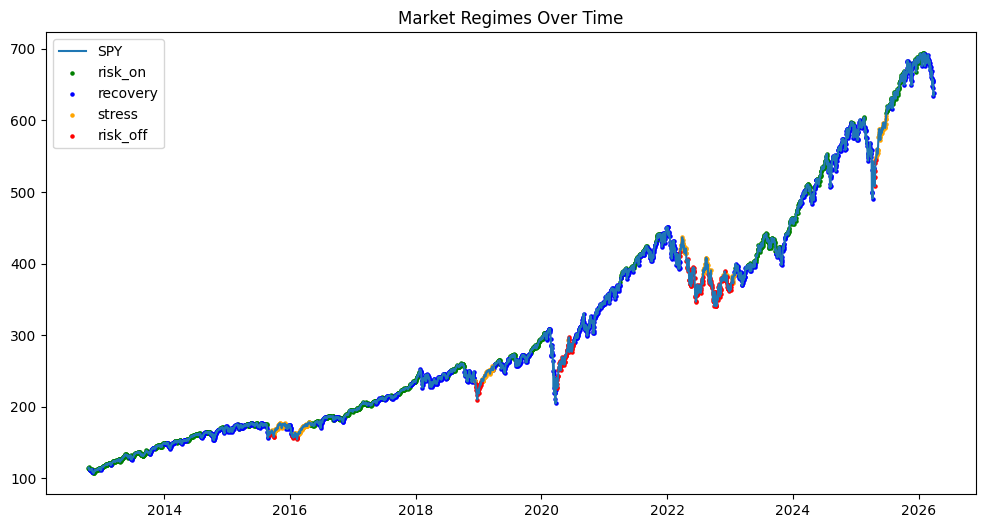

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(known_regime_df.index, known_regime_df["spy_adj_close"], label="SPY")

colors = {
    "risk_on": "green",
    "recovery": "blue",
    "stress": "orange",
    "risk_off": "red",
}

for regime, color in colors.items():
    mask = known_regime_df["regime"] == regime
    ax.scatter(
        known_regime_df.index[mask],
        known_regime_df.loc[mask, "spy_adj_close"],
        color=color,
        s=5,
        label=regime,
    )

ax.legend()
ax.set_title("Market Regimes Over Time")
plt.show()

# 4. Signal Construction

Having classified each day into a market regime, the next step is to translate
those regimes into a portfolio decision.

In this project, I treat regime classification as an input to **risk allocation**
rather than as a direct buy/sell prediction.

The basic idea is:

- maintain full exposure in favorable environments
- reduce exposure when market conditions deteriorate
- step out of the market entirely during severe stress

## 4.1 From Regimes to Signals

The distinction between **regimes** and **signals** is important.

- A **regime** describes the state of the market
- A **signal** describes the portfolio action taken in response to that state

In other words, the regime model answers:

> *What kind of market environment am I in?*

while the signal model answers:

> *Given that environment, how much exposure should I take?*

Separating these layers makes the framework more interpretable and more flexible,
since the same regime model could later be paired with different portfolio rules.

## 4.2 Exposure Mapping

In the first version of the strategy, I use the following exposure mapping:

- **Risk-on** → 100% SPY exposure
- **Recovery** → 75% SPY exposure
- **Stress** → 25% SPY exposure
- **Risk-off** → 0% SPY exposure

This mapping reflects the intuition that not all weak environments should be
treated equally.

For example, a recovery regime may still justify meaningful participation in the
market, whereas a risk-off regime suggests stepping aside entirely.

In [ ]:
from src.signals import build_signals, summarize_signal_distribution

signal_df = build_signals(known_regime_df).copy()
signal_df.head()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close,spy_ret_1d,spy_ma_50,spy_ma_200,...,vix_level,vix_change_20,tnx_change_20,rv20_low_threshold,rv20_high_threshold,regime,target_exposure,target_exposure_prev,exposure_change,rebalance_flag
date,,,,,,,,,,,,,,,,,,,,,
2012-10-16,145.539993,115.061623,108815500,15.220000,15.220000,1.720,1.720,0.010133,112.957232,107.607940,...,15.220000,0.073343,-0.092,NaN,NaN,risk_on,1.0,NaN,NaN,False
2012-10-17,146.199997,115.583389,128834100,15.070000,15.070000,1.811,1.811,0.004535,113.061985,107.689296,...,15.070000,0.085735,0.029,NaN,NaN,risk_on,1.0,1.0,0.0,False
2012-10-18,145.820007,115.282974,148108500,15.030000,15.030000,1.826,1.826,-0.002599,113.158056,107.768371,...,15.030000,0.068230,0.049,NaN,NaN,risk_on,1.0,1.0,0.0,False
2012-10-19,143.389999,113.361877,185645200,17.059999,17.059999,1.768,1.768,-0.016664,113.213819,107.836516,...,17.059999,0.220315,0.008,NaN,NaN,risk_on,1.0,1.0,0.0,False
2012-10-22,143.410004,113.377708,125578600,16.620001,16.620001,1.798,1.798,0.000140,113.266280,107.906026,...,16.620001,0.174558,0.080,NaN,NaN,risk_on,1.0,1.0,0.0,False


## 4.3 Signal Output

The signal construction layer adds a `target_exposure` column, which represents
the desired portfolio weight in SPY on each day.

It also adds helper columns that track when the target exposure changes, which
will later be useful for transaction-cost modelling and backtesting.

In [ ]:
signal_df[["regime", "target_exposure", "target_exposure_prev", "exposure_change", "rebalance_flag"]].head(15)

,regime,target_exposure,target_exposure_prev,exposure_change,rebalance_flag
date,,,,,
2012-10-16,risk_on,1.00,NaN,NaN,False
2012-10-17,risk_on,1.00,1.00,0.00,False
2012-10-18,risk_on,1.00,1.00,0.00,False
2012-10-19,risk_on,1.00,1.00,0.00,False
2012-10-22,risk_on,1.00,1.00,0.00,False
2012-10-23,recovery,0.75,1.00,-0.25,True
2012-10-24,recovery,0.75,0.75,0.00,False
2012-10-25,recovery,0.75,0.75,0.00,False
2012-10-26,risk_on,1.00,0.75,0.25,True


## 4.4 Signal Distribution

Before running the strategy, it is useful to check how often each exposure level
appears in the sample.

This helps confirm that the mapping is producing a meaningful range of portfolio
states rather than collapsing into one dominant position.

In [ ]:
summarize_signal_distribution(signal_df)

,count,proportion
target_exposure,,
1.00,1432,0.423543
0.75,1415,0.418515
0.00,267,0.078971
0.25,267,0.078971


A sensible signal distribution should reflect the broad market history:

- more high exposure during long bull-market periods
- more reduced or zero exposure during stressed episodes
- non-trivial time spent in intermediate states such as recovery

## 4.5 Exposure Over Time

A visual inspection of target exposure over time provides another useful validation step.

The expected pattern is:
- sustained high exposure during calm upward-trending markets
- partial exposure during uncertain or transitional periods
- near-zero exposure during severe dislocations

<Axes: title={'center': 'Target SPY Exposure Over Time'}, xlabel='date'>

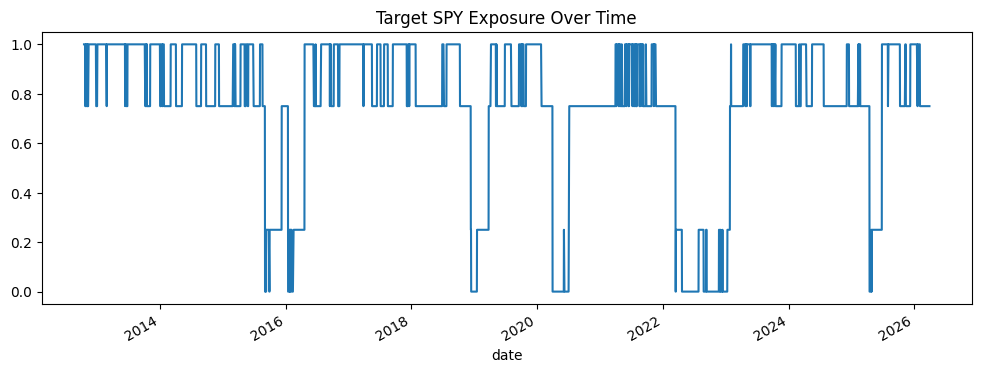

In [ ]:
signal_df["target_exposure"].plot(
    figsize=(12, 4),
    title="Target SPY Exposure Over Time",
)

## 4.6 Rebalancing Activity

Because the strategy changes exposure only when the regime changes, it is useful
to inspect how often rebalancing occurs.

This matters because a strategy that switches too frequently may look attractive
before costs but become unrealistic in practice once turnover is taken into account.

In [ ]:
signal_df["rebalance_flag"].value_counts()

rebalance_flag
False    3170
True      211
Name: count, dtype: int64

In [ ]:
signal_df["rebalance_flag"].mean()

np.float64(0.06240757172434191)

The average value of the rebalance flag gives the proportion of days on which the
target exposure changes.

This provides a simple first indication of whether the regime framework is likely
to be practical from an implementation perspective.

# 5. Backtesting Framework

The purpose of the backtest is to evaluate whether the regime-aware exposure framework
improves portfolio behaviour relative to a passive buy-and-hold allocation in SPY.

The strategy does not attempt to predict raw market returns directly. Instead, it uses
the regime model as a **risk allocation overlay**, adjusting exposure depending on
market conditions.

The benchmark is a simple buy-and-hold SPY strategy.

## 5.1 Backtesting Principles

To keep the evaluation realistic, the backtest follows several important principles:

- **No look-ahead bias**  
  Regimes and target exposures are computed using information available at time \( t \),
  but positions are only implemented at time \( t+1 \).

- **Transaction costs**  
  Exposure changes are not assumed to be free. Costs are applied based on turnover.

- **Benchmark comparison**  
  Strategy performance is evaluated relative to passive SPY exposure.

- **Sample separation**  
  The backtest is labeled into train, validation, and test periods so that results
  can later be evaluated both in-sample and out-of-sample.

## 5.2 From Exposure to Strategy Returns

The signal layer produces a `target_exposure` series, but this is not yet the actual
traded position.

To avoid look-ahead bias, the target exposure is shifted forward by one day to create
the implemented position.

Daily strategy returns are then computed as:

$$
r_t^{\mathrm{strategy}} = w_{t-1} \cdot r_t^{\mathrm{SPY}} - \mathrm{cost}_t
$$

where:

- $w_{t-1}$ is the lagged portfolio exposure
- $r_t^{\mathrm{SPY}}$ is the daily SPY return
- $\mathrm{cost}_t$ is the transaction cost incurred when exposure changes

In [ ]:
from src.backtest import (
    run_backtest,
    summarize_backtest,
    summarize_backtest_by_sample,
    get_backtest_columns,
)

backtest_df = run_backtest(signal_df).copy()
backtest_df.head()

,spy_close,spy_adj_close,spy_volume,vix_close,vix_adj_close,tnx_close,tnx_adj_close,spy_ret_1d,spy_ma_50,spy_ma_200,...,position_prev,turnover,transaction_cost_rate,transaction_cost,strategy_ret_gross,strategy_ret_net,benchmark_ret,strategy_cum_gross,strategy_cum_net,benchmark_cum
date,,,,,,,,,,,,,,,,,,,,,
2012-10-16,145.539993,115.061623,108815500,15.220000,15.220000,1.720,1.720,0.010133,112.957232,107.607940,...,0.0,0.0,0.0005,0.0000,0.000000,0.000000,0.010133,1.000000,1.000000,1.010133
2012-10-17,146.199997,115.583389,128834100,15.070000,15.070000,1.811,1.811,0.004535,113.061985,107.689296,...,0.0,1.0,0.0005,0.0005,0.004535,0.004035,0.004535,1.004535,1.004035,1.014713
2012-10-18,145.820007,115.282974,148108500,15.030000,15.030000,1.826,1.826,-0.002599,113.158056,107.768371,...,1.0,0.0,0.0005,0.0000,-0.002599,-0.002599,-0.002599,1.001924,1.001425,1.012076
2012-10-19,143.389999,113.361877,185645200,17.059999,17.059999,1.768,1.768,-0.016664,113.213819,107.836516,...,1.0,0.0,0.0005,0.0000,-0.016664,-0.016664,-0.016664,0.985228,0.984737,0.995211
2012-10-22,143.410004,113.377708,125578600,16.620001,16.620001,1.798,1.798,0.000140,113.266280,107.906026,...,1.0,0.0,0.0005,0.0000,0.000140,0.000140,0.000140,0.985365,0.984875,0.995350


## 5.3 Backtest Output

The backtest adds several new columns, including:

- `position`: the lagged implemented exposure
- `turnover`: the absolute change in position
- `transaction_cost`: cost paid when exposure changes
- `strategy_ret_gross`: strategy return before costs
- `strategy_ret_net`: strategy return after costs
- `benchmark_ret`: daily buy-and-hold SPY return
- cumulative value series for both the strategy and the benchmark

In [ ]:
backtest_cols = [col for col in get_backtest_columns() if col in backtest_df.columns]
backtest_df[backtest_cols].head(15)

,sample_period,position,position_prev,turnover,transaction_cost_rate,transaction_cost,strategy_ret_gross,strategy_ret_net,benchmark_ret,strategy_cum_gross,strategy_cum_net,benchmark_cum
date,,,,,,,,,,,,
2012-10-16,train,0.00,0.00,0.00,0.0005,0.000000,0.000000,0.000000,0.010133,1.000000,1.000000,1.010133
2012-10-17,train,1.00,0.00,1.00,0.0005,0.000500,0.004535,0.004035,0.004535,1.004535,1.004035,1.014713
2012-10-18,train,1.00,1.00,0.00,0.0005,0.000000,-0.002599,-0.002599,-0.002599,1.001924,1.001425,1.012076
2012-10-19,train,1.00,1.00,0.00,0.0005,0.000000,-0.016664,-0.016664,-0.016664,0.985228,0.984737,0.995211
2012-10-22,train,1.00,1.00,0.00,0.0005,0.000000,0.000140,0.000140,0.000140,0.985365,0.984875,0.995350
2012-10-23,train,1.00,1.00,0.00,0.0005,0.000000,-0.013876,-0.013876,-0.013876,0.971692,0.971208,0.981538
2012-10-24,train,0.75,1.00,0.25,0.0005,0.000125,-0.002122,-0.002247,-0.002829,0.969630,0.969026,0.978761
2012-10-25,train,0.75,0.75,0.00,0.0005,0.000000,0.002181,0.002181,0.002908,0.971745,0.971140,0.981607
2012-10-26,train,0.75,0.75,0.00,0.0005,0.000000,-0.000424,-0.000424,-0.000566,0.971333,0.970728,0.981052


## 5.4 Sample Splits

To support more disciplined evaluation, the backtest labels each observation as part of:

- **train**
- **validation**
- **test**

At this stage, the purpose is mainly organizational. Later, these splits allow the
results to be examined separately and help avoid drawing conclusions solely from
in-sample performance.

In [ ]:
backtest_df["sample_period"].value_counts()

sample_period
train         1561
test          1063
validation     757
Name: count, dtype: int64

In [ ]:
summarize_backtest_by_sample(backtest_df)

,n_obs,avg_daily_strategy_ret_net,avg_daily_benchmark_ret,avg_daily_turnover,rebalance_rate
sample_period,,,,,
test,1063,0.000214,0.000395,0.015522,0.055503
train,1561,0.000323,0.000467,0.016976,0.060218
validation,757,0.000437,0.001011,0.020806,0.076618


## 5.5 Cumulative Performance

A first visual comparison is to examine cumulative performance over time.

This allows the strategy to be compared directly with a passive SPY benchmark and
helps show whether the regime-based exposure framework materially changes the path
of returns.

<Axes: title={'center': 'Cumulative Performance: Strategy vs Buy-and-Hold SPY'}, xlabel='date'>

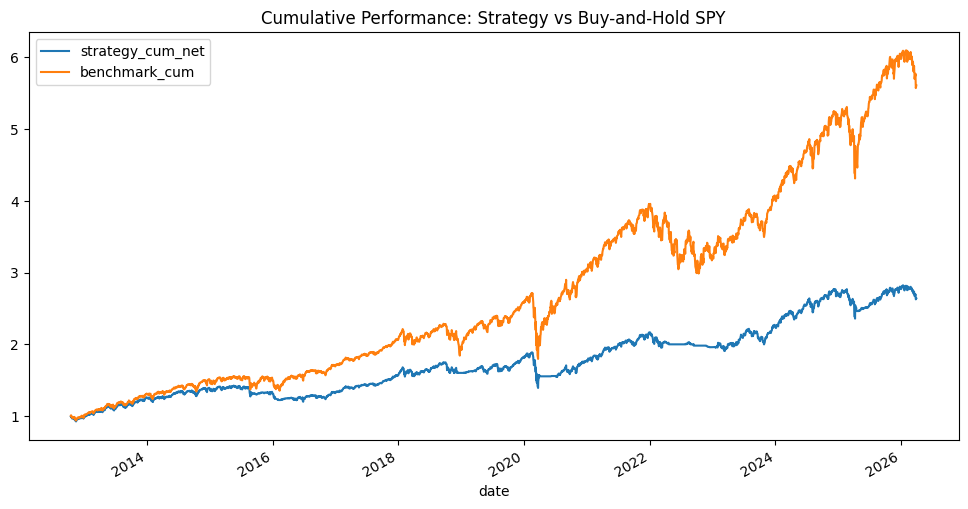

In [ ]:
backtest_df[["strategy_cum_net", "benchmark_cum"]].plot(
    figsize=(12, 6),
    title="Cumulative Performance: Strategy vs Buy-and-Hold SPY",
)

The cumulative return chart is useful for understanding not only final performance,
but also the path taken to get there.

In particular, it can show whether the strategy:
- preserves upside participation in favorable environments
- reduces losses during stressed periods
- behaves differently from buy-and-hold during major dislocations

## 5.6 Daily Return Comparison

Before moving to more advanced performance metrics, it is also useful to inspect
the daily strategy and benchmark return series directly.

In [ ]:
backtest_df[["strategy_ret_net", "benchmark_ret"]].head(10)

,strategy_ret_net,benchmark_ret
date,,
2012-10-16,0.000000,0.010133
2012-10-17,0.004035,0.004535
2012-10-18,-0.002599,-0.002599
2012-10-19,-0.016664,-0.016664
2012-10-22,0.000140,0.000140
2012-10-23,-0.013876,-0.013876
2012-10-24,-0.002247,-0.002829
2012-10-25,0.002181,0.002908
2012-10-26,-0.000424,-0.000566


In [ ]:
backtest_df[["strategy_ret_net", "benchmark_ret"]].describe().T

,count,mean,std,min,25%,50%,75%,max
strategy_ret_net,3381.0,0.000314,0.007349,-0.082068,-0.002305,0.000094,0.003811,0.078765
benchmark_ret,3381.0,0.000566,0.010600,-0.109424,-0.003585,0.000690,0.005676,0.105019


## 5.7 Turnover and Trading Costs

Because this is an allocation strategy rather than a passive benchmark, it is important
to inspect turnover and transaction-cost behaviour.

A strategy that looks attractive before costs may become less compelling if it rebalances
too frequently.

In [ ]:
backtest_df[["turnover", "transaction_cost"]].describe().T

,count,mean,std,min,25%,50%,75%,max
turnover,3381.0,0.017377,0.072806,0.0,0.0,0.0,0.0,1.0000
transaction_cost,3381.0,0.000009,0.000036,0.0,0.0,0.0,0.0,0.0005


<Axes: title={'center': 'Daily Turnover'}, xlabel='date'>

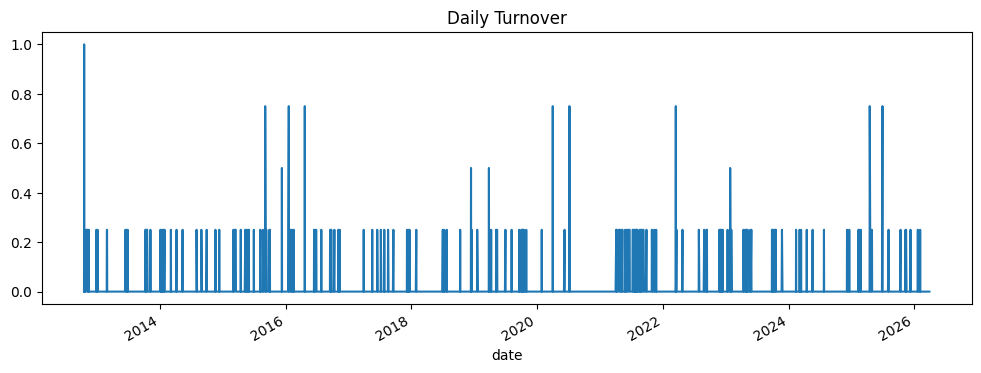

In [ ]:
backtest_df["turnover"].plot(
    figsize=(12, 4),
    title="Daily Turnover",
)

Turnover provides a simple measure of implementation intensity.

In this project, transaction costs are proportional to position changes, so turnover
is one of the key practical constraints on the strategy.

## 5.8 Full-Sample Summary

As a final first-pass check, I summarize the backtest over the full sample.

This does not yet include more advanced statistics such as Sharpe ratio or maximum
drawdown, but it does provide a basic view of:

- average daily strategy return
- average daily benchmark return
- average turnover
- rebalance frequency
- final cumulative values

In [ ]:
summarize_backtest(backtest_df)

,n_obs,avg_daily_strategy_ret_net,avg_daily_benchmark_ret,avg_daily_turnover,rebalance_rate,final_strategy_cum_net,final_benchmark_cum
0,3381,0.000314,0.000566,0.017377,0.062408,2.640543,5.603718


In [ ]:
baseline_backtest_df = backtest_df.copy()

baseline_summary = summarize_backtest(baseline_backtest_df)
baseline_summary

,n_obs,avg_daily_strategy_ret_net,avg_daily_benchmark_ret,avg_daily_turnover,rebalance_rate,final_strategy_cum_net,final_benchmark_cum
0,3381,0.000314,0.000566,0.017377,0.062408,2.640543,5.603718


<Axes: title={'center': 'Baseline Strategy vs Buy-and-Hold'}, xlabel='date'>

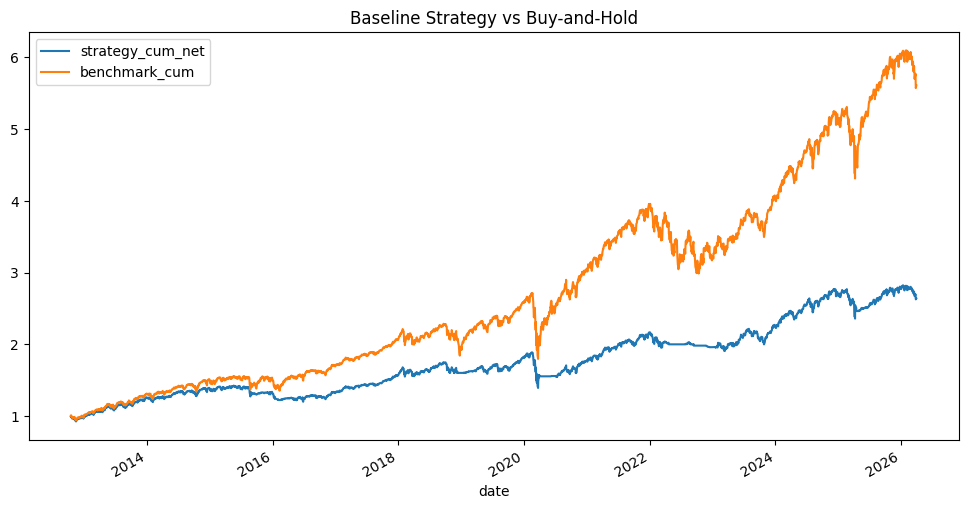

In [ ]:
baseline_backtest_df[["strategy_cum_net", "benchmark_cum"]].plot(
    figsize=(12, 6),
    title="Baseline Strategy vs Buy-and-Hold",
)

## 5.9 Baseline Results

The following results correspond to the initial exposure mapping:

- risk_on → 1.00  
- recovery → 0.75  
- stress → 0.25  
- risk_off → 0.00  

This baseline serves as a reference point for evaluating alternative exposure mappings.

# 6. Baseline Preservation and Alternative Exposure Experiment

The initial backtest provides a baseline evaluation of the regime-aware exposure framework
under the default signal mapping defined in `config.py`.

Before testing alternative portfolio constructions, it is important to preserve the baseline
results so that any subsequent changes can be compared cleanly.

To do this, I:
- store the baseline outputs in memory under separate names
- save the baseline outputs to disk
- define alternative exposure mappings directly in the notebook rather than modifying the baseline configuration

In [ ]:
from pathlib import Path

results_tables_dir = PROJECT_ROOT / "results" / "tables"
results_tables_dir.mkdir(parents=True, exist_ok=True)

baseline_signal_df = signal_df.copy()
baseline_backtest_df = backtest_df.copy()
baseline_summary = summarize_backtest(baseline_backtest_df).copy()

baseline_signal_df.to_csv(results_tables_dir / "baseline_signal.csv")
baseline_backtest_df.to_csv(results_tables_dir / "baseline_backtest.csv")
baseline_summary.to_csv(results_tables_dir / "baseline_summary.csv", index=False)

baseline_summary

## 6.1 Why preserve the baseline?

If I were to edit the default signal mapping in `config.py` and rerun the notebook,
the resulting objects would overwrite the current outputs.

Saving the baseline separately ensures that:
- the original implementation remains recoverable
- later experiments can be compared against a fixed reference point
- the notebook reflects a more disciplined research workflow

## 6.2 Alternative Exposure Mapping

The initial backtest suggests that the baseline exposure mapping may be too conservative
relative to a strongly upward-trending long-only equity benchmark.

To test whether the issue lies primarily in the **regime classification** or in the
**portfolio exposure mapping**, I keep the regime model fixed and adjust only the
exposure schedule.

This is a cleaner experiment because it changes one component at a time.

In [ ]:
alt_mapping = {
    "risk_on": 1.00,
    "recovery": 0.90,
    "stress": 0.60,
    "risk_off": 0.20,
    "unknown": 0.00,
}

alt_signal_df = build_signals(known_regime_df, mapping=alt_mapping).copy()
alt_backtest_df = run_backtest(alt_signal_df).copy()
alt_summary = summarize_backtest(alt_backtest_df).copy()

alt_summary

## 6.3 Comparing Baseline and Alternative Strategies

The purpose of this comparison is to isolate the effect of the exposure mapping.

Because the regime definitions are unchanged, any performance difference between the
two strategies should be attributable to portfolio construction rather than regime detection.

In [ ]:
comparison_df = pd.DataFrame({
    "baseline": baseline_backtest_df["strategy_cum_net"],
    "alternative": alt_backtest_df["strategy_cum_net"],
    "benchmark": baseline_backtest_df["benchmark_cum"],
})

comparison_df.plot(
    figsize=(12, 6),
    title="Baseline vs Alternative Strategy vs Buy-and-Hold",
)

In [ ]:
comparison_summary = pd.concat(
    [baseline_summary, alt_summary],
    keys=["baseline", "alternative"]
)

comparison_summary

## 6.4 Interpretation

This experiment separates two distinct questions:

1. Is the regime model economically sensible?
2. Is the regime-to-exposure mapping too conservative?

If the alternative mapping materially improves performance while using the same
regime labels, this would suggest that the main issue lies in portfolio construction
rather than in the regime framework itself.

This is an important distinction because it shows that a regime model can be
directionally reasonable even if the initial portfolio mapping is suboptimal.